In [2]:
# import required libraries
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

**Step-1: Create Graph**

In [ ]:
graph = nx.Graph() # create an empty graph

# define edges
#edges = [("A", "B"), ("A", "C"), ("B", "D"), ("C", "E"), ("D", "F"), ("E", "G"), ("F", "H"), ("G", "H")]
edges = [
    ("A", "B"), ("A", "C"), ("B", "D"), ("C", "E"),
    ("D", "F"), ("E", "G"), ("F", "H"), ("G", "H"),
    ("A", "D"), ("B", "E"), ("C", "F"), ("D", "G"), ("E", "H")
]

# add edges to the graph
graph.add_edges_from(edges)

print(graph)
print(graph.edges())


Graph with 8 nodes and 13 edges
[('A', 'B'), ('A', 'C'), ('A', 'D'), ('B', 'D'), ('B', 'E'), ('C', 'E'), ('C', 'F'), ('D', 'F'), ('D', 'G'), ('E', 'G'), ('E', 'H'), ('F', 'H'), ('G', 'H')]


**Step-2: Add additional features to each node**

In [36]:
# add additional features to each node
features = {node: np.random.rand(4) for node in graph.nodes}

for node, feature in features.items():
    graph.nodes[node]['feature'] = feature

print(features)

{'A': array([0.83633715, 0.1159976 , 0.55767173, 0.89325638]), 'B': array([0.3209735 , 0.2132067 , 0.55388619, 0.72578065]), 'C': array([0.34591252, 0.68526309, 0.03155763, 0.81843576]), 'D': array([0.91644088, 0.72835033, 0.15226712, 0.28852346]), 'E': array([0.41748416, 0.37669086, 0.12803547, 0.02487244]), 'F': array([0.5943672 , 0.87495481, 0.27993471, 0.26298484]), 'G': array([0.72301178, 0.6799822 , 0.73043347, 0.53939634]), 'H': array([0.70064429, 0.82358804, 0.02480803, 0.52194498])}


In [37]:
node_features = torch.tensor([graph.nodes[node]['feature'] for node in graph.nodes], dtype=torch.float32)
print("Node Features Tensor:")
print(node_features)

Node Features Tensor:
tensor([[0.8363, 0.1160, 0.5577, 0.8933],
        [0.3210, 0.2132, 0.5539, 0.7258],
        [0.3459, 0.6853, 0.0316, 0.8184],
        [0.9164, 0.7284, 0.1523, 0.2885],
        [0.4175, 0.3767, 0.1280, 0.0249],
        [0.5944, 0.8750, 0.2799, 0.2630],
        [0.7230, 0.6800, 0.7304, 0.5394],
        [0.7006, 0.8236, 0.0248, 0.5219]])


In [38]:
# print the adjacency matrix
adj_matrix = nx.to_numpy_array(graph)
print("Adjacency Matrix:")
print(adj_matrix)

Adjacency Matrix:
[[0. 1. 1. 1. 0. 0. 0. 0.]
 [1. 0. 0. 1. 1. 0. 0. 0.]
 [1. 0. 0. 0. 1. 1. 0. 0.]
 [1. 1. 0. 0. 0. 1. 1. 0.]
 [0. 1. 1. 0. 0. 0. 1. 1.]
 [0. 0. 1. 1. 0. 0. 0. 1.]
 [0. 0. 0. 1. 1. 0. 0. 1.]
 [0. 0. 0. 0. 1. 1. 1. 0.]]


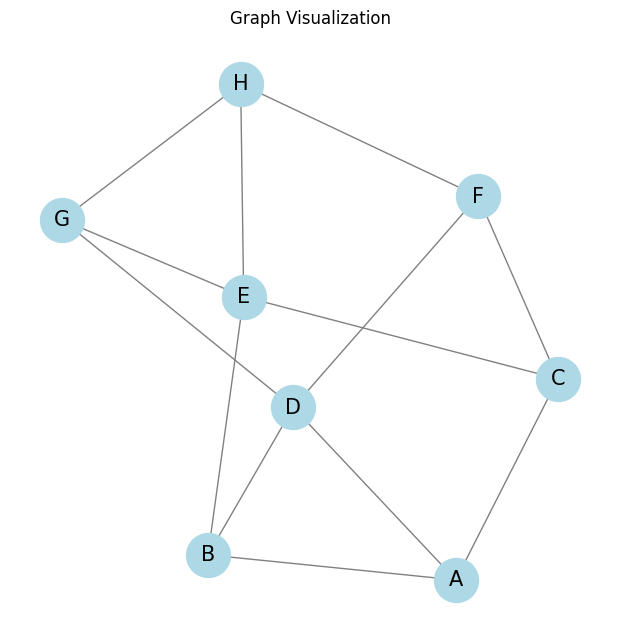

In [39]:
# visualize the graph
plt.figure(figsize=(6, 6))
pos = nx.spring_layout(graph)
nx.draw(graph, pos, with_labels=True, node_color="lightblue", edge_color="gray", node_size=1000, font_size=15)
plt.title("Graph Visualization")
plt.show()

**Step-3: Enhanced GNN model**

In [40]:
class SimpleGNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(SimpleGNN, self).__init__()
        # 4 total layers for deeper representation
        self.linear1 = nn.Linear(input_dim, hidden_dim)
        self.linear2 = nn.Linear(hidden_dim, hidden_dim)
        self.linear3 = nn.Linear(hidden_dim, hidden_dim)
        self.linear4 = nn.Linear(hidden_dim, output_dim)

    def forward(self, features, adj_matrix):
        h = self.linear1(features)
        h = torch.relu(h)

        # Aggregate neighbor info
        h = torch.matmul(torch.tensor(adj_matrix, dtype=torch.float32), h)
        h = self.linear2(h)
        h = torch.relu(h)

        # Additional layers for deeper representation
        h = self.linear3(h)
        h = torch.relu(h)
        h = self.linear4(h)

        return torch.softmax(h, dim=1)

In [41]:
# Initialize the model
model = SimpleGNN(input_dim=features['A'].shape[0], hidden_dim=8, output_dim=2)
print(model)

SimpleGNN(
  (linear1): Linear(in_features=4, out_features=8, bias=True)
  (linear2): Linear(in_features=8, out_features=8, bias=True)
  (linear3): Linear(in_features=8, out_features=8, bias=True)
  (linear4): Linear(in_features=8, out_features=2, bias=True)
)


In [42]:
# assign random binary labels
labels = torch.tensor(np.random.randint(0, 2, size=(len(graph.nodes),)), dtype=torch.long)
print("Labels:", labels)

Labels: tensor([0, 1, 1, 0, 1, 0, 1, 0])


**Find optimal epochs**

In [43]:
def train_and_get_loss(num_epochs, lr=0.01):
    '''Train the GNN model and return the list of losses over epochs.'''

    # Define optimizer and loss function
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    losses = []

    # training loop
    for epoch in range(num_epochs):
        optimizer.zero_grad()
        predictions = model(node_features, adj_matrix)
        loss = loss_fn(predictions, labels)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    return losses

In [44]:
# try multiple epoch settings to find optimal point
epoch_candidates = [50, 100, 200, 300, 500]
loss_results = {}

In [45]:
# evaluate different epoch settings
for e in epoch_candidates:
    losses = train_and_get_loss(e, lr=0.01)
    loss_results[e] = losses[-1]
    print(f"Epochs: {e}, Final Loss: {losses[-1]:.4f}")

Epochs: 50, Final Loss: 0.4475
Epochs: 100, Final Loss: 0.4383
Epochs: 200, Final Loss: 0.4383
Epochs: 300, Final Loss: 0.4383
Epochs: 500, Final Loss: 0.4383


In [47]:
# find optimal epoch count
optimal_epochs = min(loss_results, key=loss_results.get)
print(f"\nOptimal number of epochs: {optimal_epochs}")


Optimal number of epochs: 300


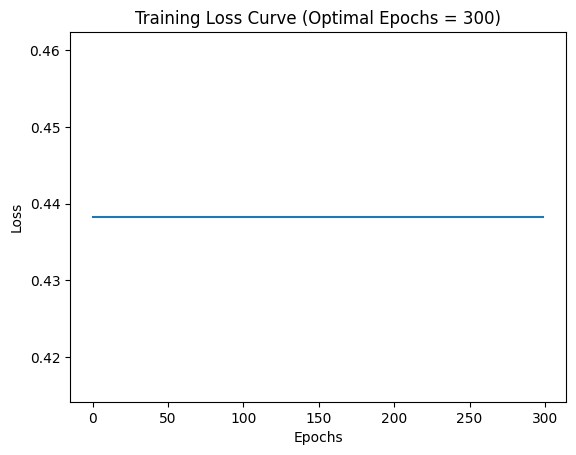

In [48]:
# train final model with optimal epochs
final_losses = train_and_get_loss(optimal_epochs, lr=0.01)

plt.plot(range(optimal_epochs), final_losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title(f"Training Loss Curve (Optimal Epochs = {optimal_epochs})")
plt.show()

**Analyze learning rate**

In [49]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
loss_fn = nn.CrossEntropyLoss()
epochs = 300
losses = []

In [50]:
# training loop
for epoch in range(epochs):
    optimizer.zero_grad()
    predictions = model(node_features, adj_matrix)
    loss = loss_fn(predictions, labels)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 50, Loss: 0.4383
Epoch 100, Loss: 0.4383
Epoch 150, Loss: 0.4383
Epoch 200, Loss: 0.4383
Epoch 250, Loss: 0.4383
Epoch 300, Loss: 0.4383


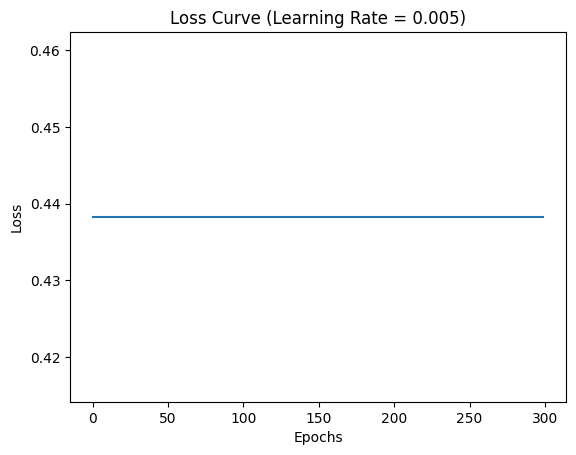

In [51]:
plt.plot(range(epochs), losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curve (Learning Rate = 0.005)")
plt.show()